In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
# from matplotlib.colors ListedColormap
from matplotlib.colors import ListedColormap

In [3]:
x = np.array([
    [1,7],
    [2,8],
    [3,7],
    [4,6],
    [5,5],
    [5,6]
])
target = np.array(['Fail','Fail','Fail','Pass','Pass','Pass'])

In [4]:
le = LabelEncoder()
y = le.fit_transform(target)
y

array([0, 0, 0, 1, 1, 1])

In [32]:
k = 3

In [34]:
model = KNeighborsClassifier(n_neighbors=k)
model.fit(x,y)

KNeighborsClassifier(n_neighbors=3)

In [6]:
new_student = np.array([[3,6.5]])
prediction = model.predict(new_student)
print("prediction",le.inverse_transform(prediction)[0])

prediction Fail


# create grid 

In [7]:
x_min,x_max = x[:,0].min()-1,x[:,0].max()+1
y_min,y_max = x[:1].min()-1, x[:,1].max()+1
xx,yy = np.meshgrid(np.arange(x_min,x_max,0.1),np.arange(y_min,y_max,0.1))

In [8]:
# predict each point in the grid 
Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

In [9]:
Z

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(90, 60))

In [10]:
cmap_light = ListedColormap(["#FFAAAA","#AAFFAA"])
cmap_bold = {0:'red',1:'green'}

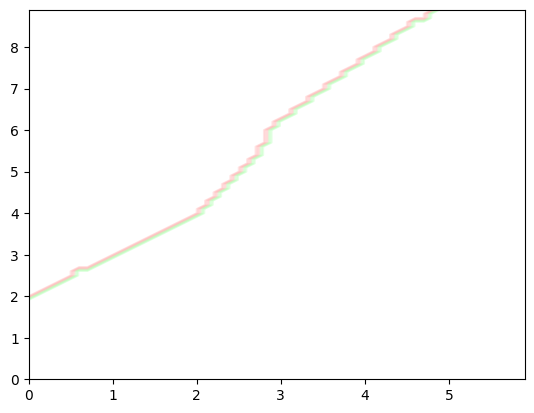

In [11]:
plt.contour(xx,yy,Z,alpha = 0.3,cmap = cmap_light)

plt.show()

In [12]:
# for class_value in np.unique(y):
#     plt.scatter(x[y=class_value,0] , x[y=class_value,1]),
#     c = cmap_bold[class_value]
#     label = le.inverse_transform([class_value])[0],edgecolor = 'K',s = 100)

# error show code 

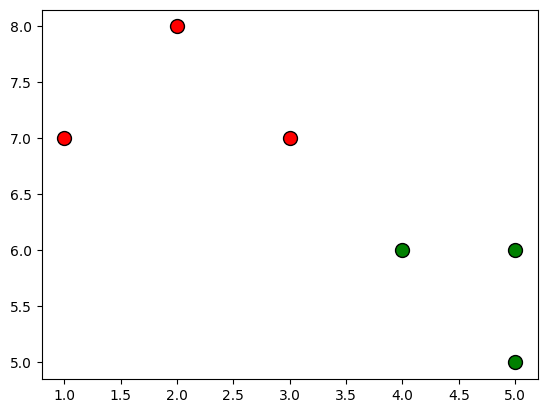

In [13]:
for class_value in np.unique(y):
    plt.scatter(
        x[y == class_value, 0],
        x[y == class_value, 1],
        c=[cmap_bold[class_value]],
        label=le.inverse_transform([class_value])[0],
        edgecolor="k",
        s=100
    )

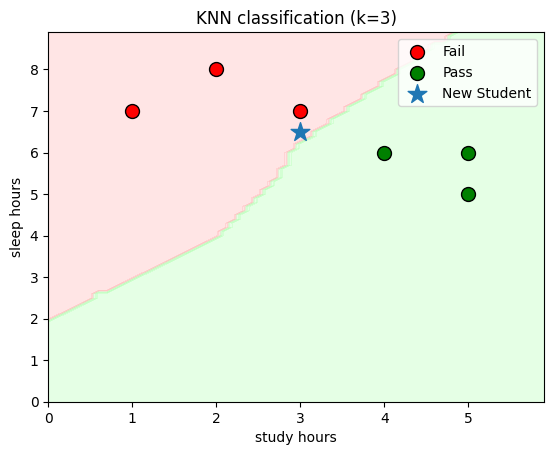

In [40]:
plt.contourf(xx,yy,Z,alpha = 0.3,cmap = cmap_light)

for class_value in np.unique(y):
    plt.scatter(
        x[y == class_value, 0],
        x[y == class_value, 1],
        c=[cmap_bold[class_value]],
        label=le.inverse_transform([class_value])[0],
        edgecolor="k",
        s=100
    )

plt.scatter(new_student[0,0], new_student[0,1], marker="*", s= 200,
           label = "New Student")
plt.xlabel("study hours")
plt.ylabel("sleep hours")
# plt.title(F"KNN classification {k = {k}}")
plt.title(f"KNN classification (k={k})")
plt.legend()
plt.show()
# plt.show()

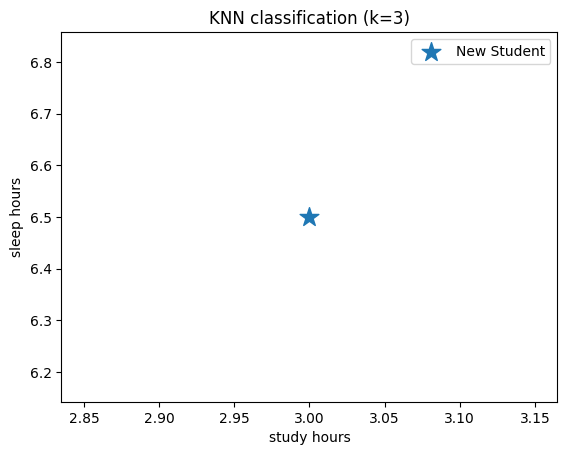